# Exercícios — Cálculo e Gradiente Descendente

**Tema:** Álgebra Linear e Otimização › Cálculo e Gradiente Descendente

Resolva antes de olhar o gabarito. A estrutura é sempre a mesma: enunciado,
célula de resposta, gabarito comentado.

**Dificuldade:** 🟢 base · 🟡 aplicação · 🔴 síntese

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(123)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
np.set_printoptions(precision=4, suppress=True)
print("ambiente pronto")

ambiente pronto


---
## Exercício 1 🟢 — Gradient checking

Para $f(x, y, z) = x^2 y + y z^3 - 2xz$, o gradiente analítico é:
$\nabla f = (2xy - 2z,\; x^2 + z^3,\; 3yz^2 - 2x)$.

Implemente `f` e o gradiente numérico (diferença central), e verifique contra
o gradiente analítico em 3 pontos aleatórios. Reporte o erro relativo de cada
um.

In [2]:
# --- sua resposta ---

### Gabarito 1

In [3]:
def f(v):
    x, y, z = v
    return x**2 * y + y * z**3 - 2 * x * z


def grad_analitico(v):
    x, y, z = v
    return np.array([2 * x * y - 2 * z, x**2 + z**3, 3 * y * z**2 - 2 * x])


def gradiente_numerico(f, v, h=1e-6):
    grad = np.zeros_like(v, dtype=float)
    for i in range(len(v)):
        v_mais, v_menos = v.copy(), v.copy()
        v_mais[i] += h
        v_menos[i] -= h
        grad[i] = (f(v_mais) - f(v_menos)) / (2 * h)
    return grad


for _ in range(3):
    v = rng.uniform(-3, 3, 3)
    g_num, g_ana = gradiente_numerico(f, v), grad_analitico(v)
    erro_relativo = np.linalg.norm(g_num - g_ana) / (np.linalg.norm(g_ana) + 1e-12)
    print(f"v={np.round(v, 3)}  numérico={np.round(g_num, 4)}  "
          f"analítico={np.round(g_ana, 4)}  erro rel.={erro_relativo:.2e}")

v=[ 1.094 -2.677 -1.678]  numérico=[ -2.5024  -3.5263 -24.7973]  analítico=[ -2.5024  -3.5263 -24.7973]  erro rel.=1.33e-10
v=[-1.894 -1.945  1.873]  numérico=[  3.62    10.1525 -16.6684]  analítico=[  3.62    10.1525 -16.6684]  erro rel.=4.83e-11
v=[ 2.54  -1.341  1.919]  numérico=[-10.6473  13.5136 -19.8829]  analítico=[-10.6473  13.5136 -19.8829]  erro rel.=1.49e-10


---
## Exercício 2 🟢 — Classificando pontos críticos pela Hessiana

Para cada Hessiana abaixo (constante, de uma forma quadrática), calcule os
autovalores e classifique o ponto crítico como mínimo, máximo ou sela.

In [4]:
H1 = np.array([[5.0, 1.0], [1.0, 3.0]])
H2 = np.array([[-2.0, 0.5], [0.5, -4.0]])
H3 = np.array([[4.0, 3.0], [3.0, 1.0]])

# --- sua resposta ---

### Gabarito 2

In [5]:
for nome, H in [("H1", H1), ("H2", H2), ("H3", H3)]:
    autoval = np.linalg.eigvalsh(H)
    if np.all(autoval > 0):
        classe = "mínimo local"
    elif np.all(autoval < 0):
        classe = "máximo local"
    else:
        classe = "ponto de sela"
    print(f"{nome}: autovalores = {autoval}   -> {classe}")

H1: autovalores = [2.5858 5.4142]   -> mínimo local
H2: autovalores = [-4.118 -1.882]   -> máximo local
H3: autovalores = [-0.8541  5.8541]   -> ponto de sela


---
## Exercício 3 🟡 — Achando a taxa de aprendizado que diverge

Para $f(x) = 3x^2$ (unidimensional, $f'(x) = 6x$), gradiente descendente com
taxa $\eta$ tem solução exata $x_{t} = (1 - 6\eta)^t x_0$. Encontre
analiticamente o valor de $\eta$ acima do qual a sequência diverge (em
magnitude). Confirme numericamente simulando 30 iterações para $\eta$ um
pouco abaixo, exatamente no limiar, e um pouco acima desse valor.

In [6]:
# --- sua resposta ---

### Gabarito 3

In [7]:
# a sequência diverge quando |1 - 6*eta| > 1, ou seja, eta > 2/6 = 1/3 (ou eta < 0)
eta_limiar = 1 / 3
print(f"eta limiar (analítico): {eta_limiar:.6f}")

x0 = 2.0
for eta, nome in [(eta_limiar * 0.8, "abaixo do limiar"),
                  (eta_limiar, "exatamente no limiar"),
                  (eta_limiar * 1.2, "acima do limiar")]:
    x = x0
    trajetoria = [x]
    for _ in range(30):
        x = x - eta * 6 * x
        trajetoria.append(x)
    print(f"\n{nome} (eta={eta:.4f}): últimos 5 valores = "
          f"{np.round(trajetoria[-5:], 4)}")

eta limiar (analítico): 0.333333

abaixo do limiar (eta=0.2667): últimos 5 valores = [ 0. -0.  0. -0.  0.]

exatamente no limiar (eta=0.3333): últimos 5 valores = [ 2. -2.  2. -2.  2.]

acima do limiar (eta=0.4000): últimos 5 valores = [ 12599.6628 -17639.528   24695.3391 -34573.4748  48402.8647]


**Confirmação:** abaixo do limiar, a sequência converge suavemente a 0.
Exatamente no limiar, ela oscila entre $+x_0$ e $-x_0$ para sempre (nem
converge nem diverge — um caso de fronteira). Acima do limiar, a magnitude
cresce a cada passo — diverge. O fator $(1-6\eta)$ é exatamente o autovalor
da "matriz de iteração" do gradiente descendente nesse problema 1D, e a
condição de convergência $|1-6\eta| < 1$ generaliza diretamente para
$|1 - \eta\lambda| < 1$ em qualquer autovalor $\lambda$ da Hessiana — a razão
formal de existir um $\eta$ máximo seguro em função do maior autovalor.

---
## Exercício 4 🟡 — Comparando GD, momentum e Adam num "vale estreito"

Implemente gradiente descendente puro, com momentum ($\mu=0.9$) e Adam
(parâmetros padrão: $\beta_1=0.9$, $\beta_2=0.999$) para
$f(x,y) = 0.02x^2 + 8y^2$, partindo de $(5, 5)$. Use a mesma taxa de
aprendizado "segura" para GD puro ($\eta \approx 1.9/\lambda_{max}$) nos três,
rode 60 iterações, e compare quantas iterações cada um leva para chegar a
menos de 1% da distância inicial ao mínimo.

In [8]:
# --- sua resposta ---

### Gabarito 4

GD puro      iterações até <1% da distância inicial: None
momentum     iterações até <1% da distância inicial: None
Adam         iterações até <1% da distância inicial: 11


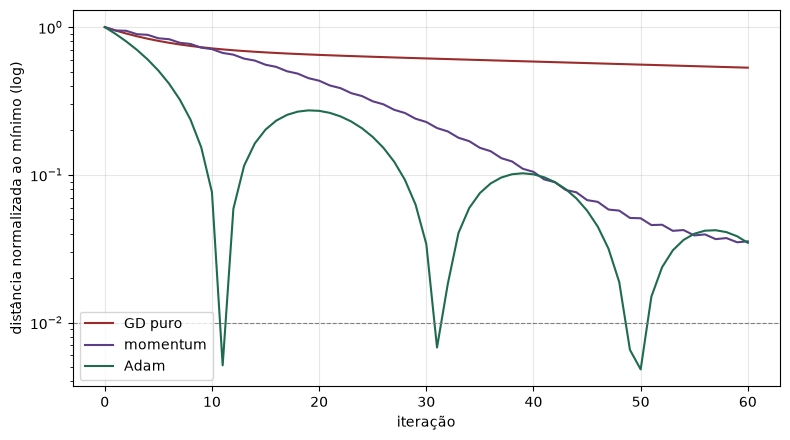

In [9]:
def grad_vale(v):
    x, y = v
    return np.array([0.04 * x, 16 * y])


def gd_puro(grad_fn, v0, eta, n_iter):
    v = v0.copy()
    traj = [v.copy()]
    for _ in range(n_iter):
        v = v - eta * grad_fn(v)
        traj.append(v.copy())
    return np.array(traj)


def gd_momentum(grad_fn, v0, eta, mu, n_iter):
    v = v0.copy()
    vel = np.zeros_like(v)
    traj = [v.copy()]
    for _ in range(n_iter):
        vel = mu * vel + grad_fn(v)
        v = v - eta * vel
        traj.append(v.copy())
    return np.array(traj)


def adam(grad_fn, v0, eta, n_iter, beta1=0.9, beta2=0.999, eps=1e-8):
    x = v0.copy()
    m, vv = np.zeros_like(x), np.zeros_like(x)
    traj = [x.copy()]
    for t in range(1, n_iter + 1):
        g = grad_fn(x)
        m = beta1 * m + (1 - beta1) * g
        vv = beta2 * vv + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = vv / (1 - beta2**t)
        x = x - eta * m_hat / (np.sqrt(v_hat) + eps)
        traj.append(x.copy())
    return np.array(traj)


v0 = np.array([5.0, 5.0])
eta_segura = 1.9 / 16  # maior autovalor da Hessiana é 16

traj_puro = gd_puro(grad_vale, v0, eta_segura, 60)
traj_mom = gd_momentum(grad_vale, v0, eta_segura, mu=0.9, n_iter=60)
traj_adam = adam(grad_vale, v0, eta=0.5, n_iter=60)

dist0 = np.linalg.norm(v0)
for nome, traj in [("GD puro", traj_puro), ("momentum", traj_mom), ("Adam", traj_adam)]:
    distancias = np.linalg.norm(traj, axis=1) / dist0
    abaixo_1pct = np.where(distancias < 0.01)[0]
    resultado = abaixo_1pct[0] if len(abaixo_1pct) else None
    print(f"{nome:<12s} iterações até <1% da distância inicial: {resultado}")

fig, ax = plt.subplots(figsize=(8, 4.5))
for nome, traj, cor in [("GD puro", traj_puro, VERMELHO),
                        ("momentum", traj_mom, ROXO), ("Adam", traj_adam, VERDE)]:
    ax.semilogy(np.linalg.norm(traj, axis=1) / dist0, color=cor, label=nome)
ax.axhline(0.01, color="gray", ls="--", lw=0.8)
ax.set_xlabel("iteração"); ax.set_ylabel("distância normalizada ao mínimo (log)")
ax.legend(); plt.tight_layout(); plt.show()

**Leitura esperada:** GD puro é o mais lento — a taxa segura é limitada pelo
eixo mais íngreme ($y$), o que faz progresso mínimo no eixo raso ($x$).
Momentum acelera ao longo da direção consistente. Adam, ao escalar cada
coordenada pela sua própria magnitude de gradiente, essencialmente
"equaliza" o vale — convergindo muito mais rápido nesse tipo de problema mal
condicionado.

---
## Exercício 5 🔴 — Medindo o efeito real do condicionamento numa regressão

Gere um dataset de regressão com 2 features altamente desbalanceadas em
escala: `x1 ~ N(0, 1)` e `x2 ~ N(0, 1000)`. Calcule o número de condição da
Hessiana do MSE ($2X^\top X/n$) antes e depois de padronizar. Treine
gradiente descendente batch por 500 épocas nos dois casos (escolha uma taxa
de aprendizado razoável para cada, testando algumas opções) e compare a
curva de perda. Confirme que o modelo padronizado converge em muito menos
épocas para o mesmo nível de erro.

In [10]:
# --- sua resposta ---

### Gabarito 5

número de condição — bruto:       1.030e+06
número de condição — padronizado: 1.049e+00


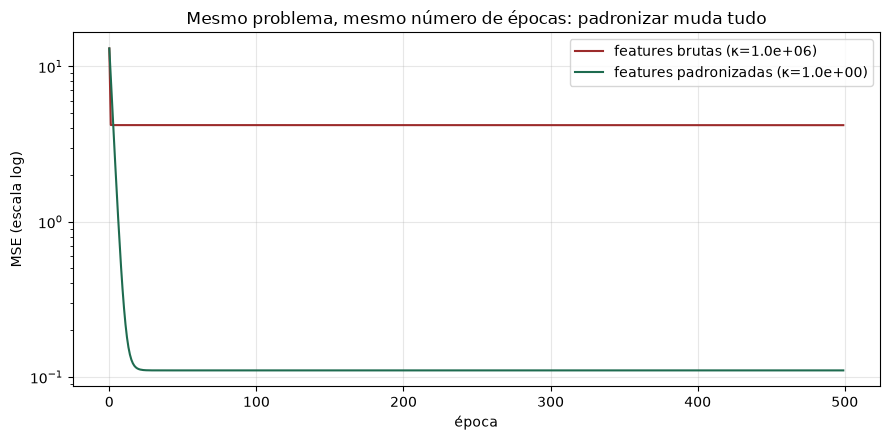


MSE após 500 épocas — bruto: 4.1830   padronizado: 0.110242


In [11]:
n = 500
x1 = rng.normal(0, 1, n)
x2 = rng.normal(0, 1000, n)
X_bruto = np.column_stack([x1, x2])
beta_real = np.array([2.0, 0.003])
y = X_bruto @ beta_real + rng.normal(0, 0.3, n)

X_padronizado = (X_bruto - X_bruto.mean(0)) / X_bruto.std(0)


def hessiana(X):
    return (2 / len(X)) * X.T @ X


cond_bruto = np.linalg.cond(hessiana(X_bruto))
cond_padronizado = np.linalg.cond(hessiana(X_padronizado))
print(f"número de condição — bruto:       {cond_bruto:.3e}")
print(f"número de condição — padronizado: {cond_padronizado:.3e}")


def gd_batch(X, y, eta, n_epocas):
    beta = np.zeros(X.shape[1])
    historico = []
    for _ in range(n_epocas):
        residuo = X @ beta - y
        grad = (2 / len(y)) * X.T @ residuo
        beta = beta - eta * grad
        historico.append(np.mean(residuo ** 2))
    return beta, historico


# eta pequena o bastante para não divergir no caso bruto, mal condicionado
# (o maior autovalor da Hessiana aqui é ~2e6, então eta precisa ser bem < 1/2e6)
_, hist_bruto = gd_batch(X_bruto, y, eta=5e-7, n_epocas=500)
_, hist_padronizado = gd_batch(X_padronizado, y, eta=0.1, n_epocas=500)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_bruto, color=VERMELHO, label=f"features brutas (κ={cond_bruto:.1e})")
ax.plot(hist_padronizado, color=VERDE, label=f"features padronizadas (κ={cond_padronizado:.1e})")
ax.set_yscale("log")
ax.set_xlabel("época"); ax.set_ylabel("MSE (escala log)")
ax.set_title("Mesmo problema, mesmo número de épocas: padronizar muda tudo")
ax.legend(); plt.tight_layout(); plt.show()

print(f"\nMSE após 500 épocas — bruto: {hist_bruto[-1]:.4f}   "
      f"padronizado: {hist_padronizado[-1]:.6f}")

**A demonstração central do módulo, em um único experimento:** o mesmo
problema, resolvido pelo mesmo algoritmo, com o mesmo número de épocas, tem
desempenho completamente diferente dependendo só da escala das features. Não
é um problema de "escolher melhor o eta" no caso bruto — o número de
condição limita fundamentalmente a taxa de aprendizado segura, e por isso
limita a velocidade de convergência. Padronizar ataca a causa raiz.

---
## Fechamento

- Gradient checking é a forma padrão (e barata) de verificar uma derivada
  implementada manualmente.
- Autovalores da Hessiana classificam pontos críticos sem ambiguidade.
- Existe sempre uma taxa de aprendizado máxima segura, ditada pelo maior
  autovalor da Hessiana — ultrapassá-la causa divergência, não só lentidão.
- Momentum e Adam não são "truques" — eles atacam diretamente o problema do
  mau condicionamento, cada um de um jeito diferente.
- Padronizar features é uma intervenção de otimização, não só de
  pré-processamento — o efeito no número de condição é mensurável e grande.

→ Este é o fim do tema **Álgebra Linear e Otimização**. A partir daqui, os
temas de modelagem (Aprendizado Supervisionado, Deep Learning) vão usar
projeção, decomposição espectral e gradiente descendente como ferramentas já
dominadas, sem reconstruí-las do zero a cada vez.